# Illustration de la théorie des modes normaux dans le guide d'onde idéal

In [1]:
import os
import sys
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

# Load usefull functions
import source.global_constants as g 
from publication.publication_figure import PubFigure, LargeFigure, SmallFigure
from propa.ideal_waveguide import (
    psi,
    psi_normalised,
    h,
    field,
    plot_tl,
    nb_propagating_modes,
)

from propa.kraken_toolbox.src.kraken_testcase import (
    KrakenTestCase,
    DomainProperties,
    SourceProperties,
    ReceiverProperties,
    KrakenProperties,
)
from propa.kraken_toolbox.src.kraken_env import (
    KrakenTopHalfspace,
    KrakenMedium,
    KrakenBottomHalfspace,
    KrakenAttenuation,
    KrakenField,
    Bathymetry,
)
from propa.kraken_toolbox.src.kraken_manager import KrakenManager
from propa.kraken_toolbox.plot_utils import plotshd, plotmode
from propa.kraken_toolbox.utils import default_nb_rcv_z
from signals.AcousticComponent import AcousticSource
from source.signal_generator import SignalGenerator
from source.ssp_profiles import SSPProfile
from misc import mult_along_axis

import matplot2tikz

pfig = PubFigure()

folder_root = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\illustration\general_ocean_acoustics\modal_theory\basic_modal_features"

# Formulation générale 

Pour un signal source large bande $S(f)$, le champ de pression reçu à la profondeur $z$ après propagation sur une distance radiale $r$ est donnée par :

$
    p(f, r, z) \simeq S(f) \times \frac{e^{i\pi/4}}{\rho(z_s) \sqrt{8 \pi}}  \sum_{n=1}^{\infty} \Psi_n(z_s) \Psi_n(z) \frac{e^{-ik_{n} r}}{\sqrt{k_{n} r}}
$

Dans la suite on note,

$
    Q_s =  \frac{e^{i\pi/4}}{\rho(z_s) \sqrt{8 \pi}}
$

Pour un récepteur $m$ de position $\mathbf{x_m}(r_m, z_m)$ et une source j de position $\mathbf{x_{s_j}}(r_{s_j}, z_{s_j})$, la fonction de transfert acoustique associée est donnée par :

$
    H_{mj} = Q_j \sum_{n=1}^{\infty} \Psi_n(z_{s_j}) \Psi_n(z_m) \frac{e^{-ik_{n} r_{mj}}}{\sqrt{k_{n} r_{mj}}}
$


## Cas d'étude : le guide d'onde idéal 
 
L'objectif est d'ici d'illustrer quelques propriétés de la théorie modale avec le cas simple du guide d'onde idéal (fond et surface parfaitement réfléchissant : p(z=0) = 0 et p(z = D) = 0)


Les fonctions modales du guide d'onde idéal sont données par,

$    
\Psi_m(z) = \sqrt{\frac{2 \rho}{D}} \sin(k_{zm} z)
$

Les fonctions $\Psi_m$ sont les fonctions propres associées aux valeurs propres $k_{rm}$ vérifiant :

$    
k_{rm} = \sqrt{ k^2 - k_{zm}^2}                                                                   
    = \sqrt{ \frac{\omega^2}{c_0^2} - \left ( \frac{m\pi}{D}  \right )^2 }, \quad m \in \mathbb{N}
$

### Paramètres du problème

In [2]:
# Parameters
D = 1000 # Depth of the waveguide
# Receiver
r_rcv = 0 # Range of receiver 
z_rcv = 950 # Depth of receiver
# Source
z_src= 100 # Depth of source 
r_src = 1e5 # Range of source 
# Signal
f = 25 # Frequency in Hz

# TL grid properties
ngrid = 400 # Number of grid points along each dimension
rmax = 50 * 1e3 # Maximum range in m
r_grid = np.linspace(1, rmax, ngrid)
z_grid = np.linspace(0, D, ngrid)
rr, zz = np.meshgrid(r_grid, z_grid)


### Fonctions modales

In [3]:
# Derive first three modes
modes = [1, 2, 3]
modal_fcts = []
z = np.linspace(0, D, int(1e4)) # Depths vector for modal functions
for m in modes:


    psi_m = psi_normalised(m=m, z=z, depth=D, rho=g.rho_w, bottom_bc="pressure_release")
    # psi_m = psi(m=m, z=z, depth=D, bottom_bc="pressure_release")

    # Cast to complex to match with the general form of the modal function
    psi_m = psi_m.astype(complex)
    modal_fcts.append(psi_m)

modal_fcts = np.array(modal_fcts)

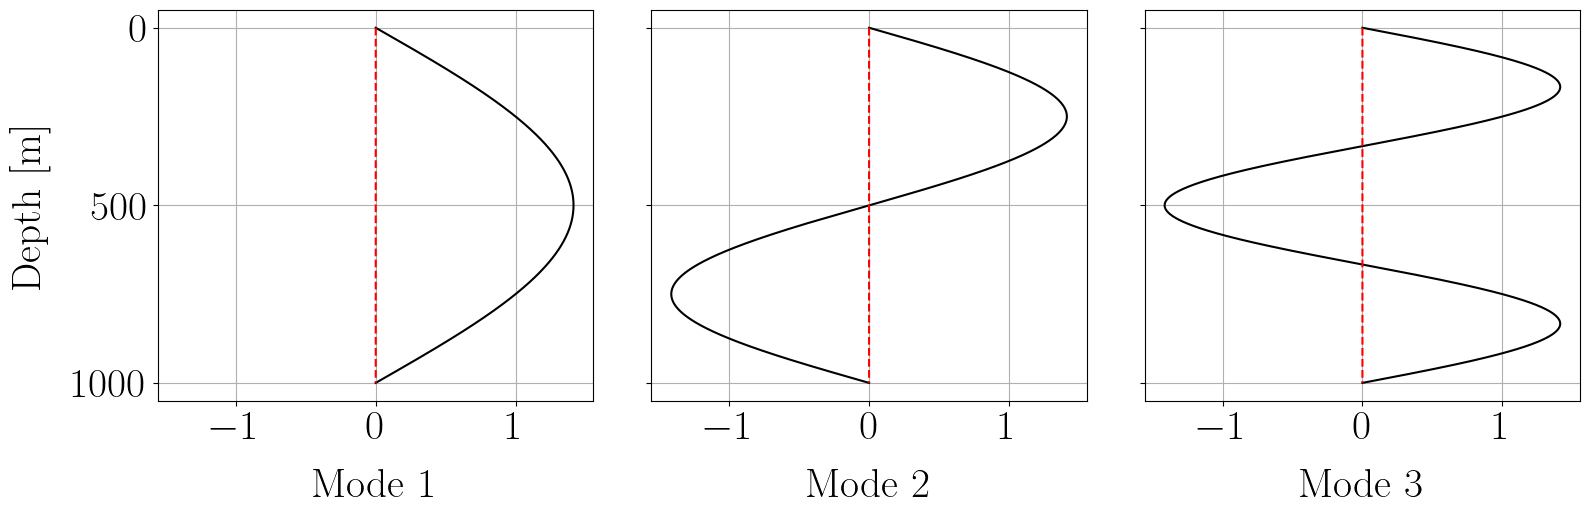

In [4]:
# Plot modal functions
lfig = LargeFigure()

fig, axs = plt.subplots(1, len(modes), sharey=True)
# Revert y-axis
axs[0].invert_yaxis()

max_amp = np.max(np.abs(modal_fcts))
axs[0].set_ylabel("Depth [m]")

for i, m in enumerate(modes):
    axs[i].plot(np.real(modal_fcts[i]), z, label=f"Real", linestyle="-", color="k")
    axs[i].plot(np.imag(modal_fcts[i]), z, label=f"Im", linestyle="--", color="r")
    axs[i].set_xlabel(f"Mode {m}")
    axs[i].set_xlim([-1.1 * max_amp, 1.1 * max_amp])
    axs[i].grid()


# Save figure as pdf
# plt.subplots_adjust(wspace=2)

fpath = os.path.join(folder_root, "ideal_waveguide_3first_modes.pdf")
plt.savefig(fpath, dpi=300)

# # Save figure as tikz
# tikz_fpath = os.path.join(folder_root, "ideal_waveguide_3first_modes.tex")
# matplot2tikz.save(tikz_fpath)

## Pertes par transmission

$TL = -10 \times log_{10} (|p|^2 / |p_0|^2)$

In [5]:
# Derive transfert functions for different number of modes
n_modes = [1, 2, 3, None]
fields = []
for n in n_modes:
    # h(f, z_src, z=z_grid, r=r_grid, depth=D, bottom_bc="pressure_release", n=n)
    ff, rr, zz, p_field = field(f=f, z_src=z_src, z=z_grid, r=r_grid, depth=D, bottom_bc="pressure_release", n=n)
    fields.append(p_field)
fields = np.array(fields)


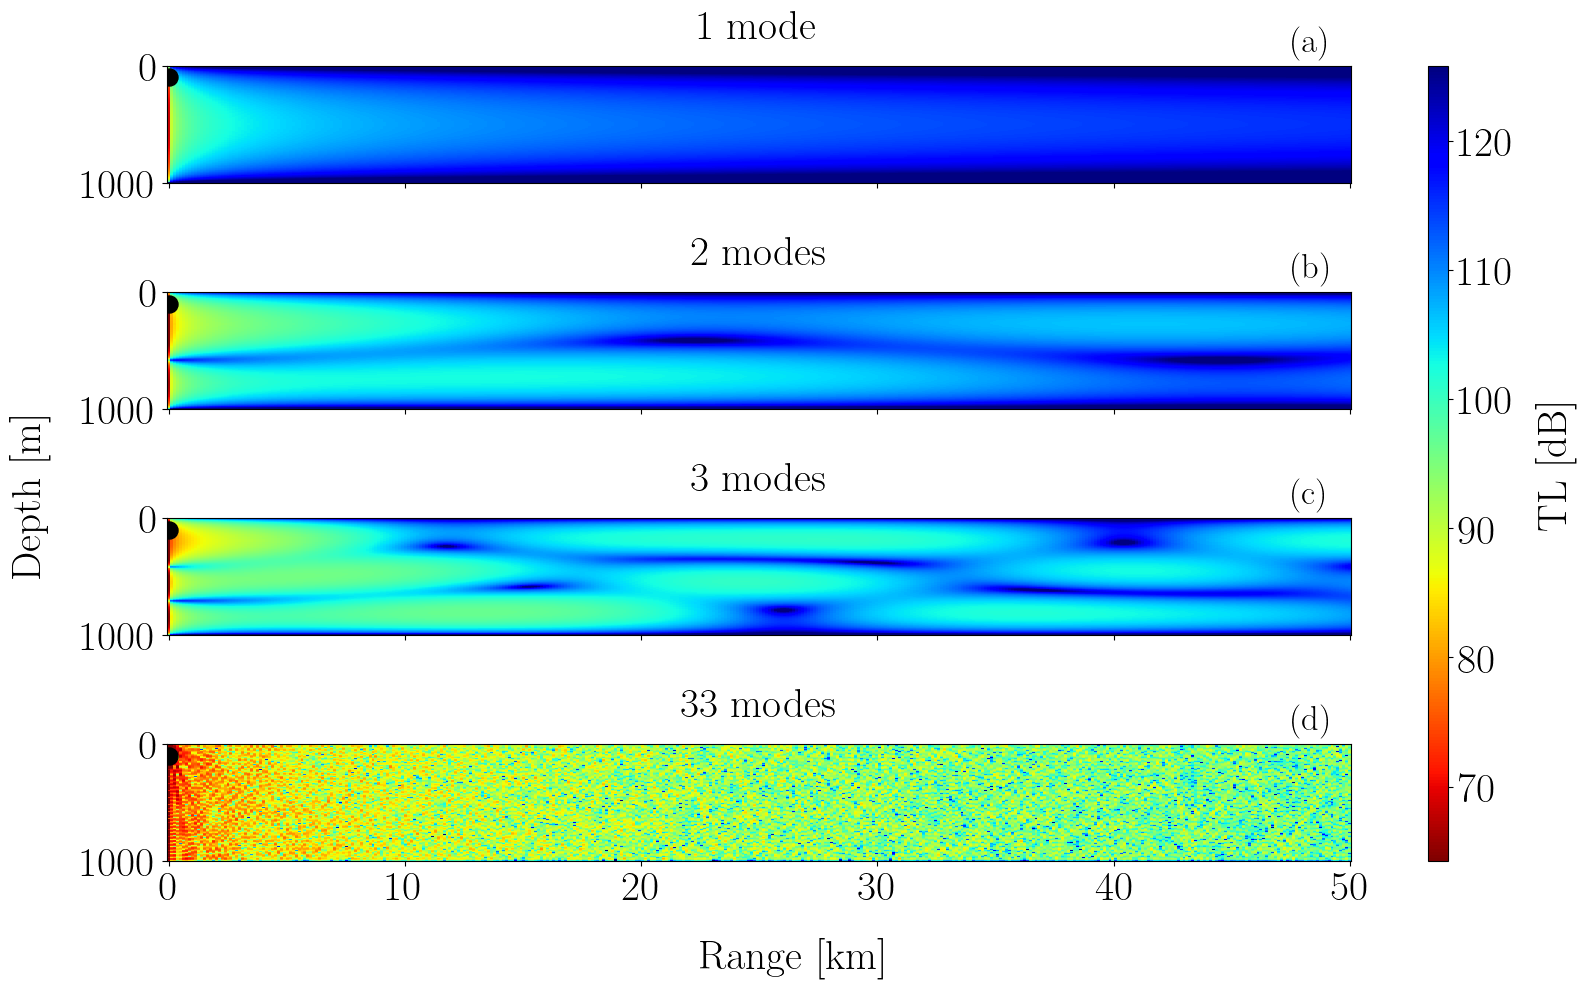

In [6]:
sfig = LargeFigure(size=(16, 10))

# Plot tl
n_max = nb_propagating_modes(f, c=1500, depth=D, bottom_bc="pressure_release")

# Derive TLs
# Slice to get the pressure field at the single frequency
p_field = fields[:, 0, ...]
# Derive TL from the pressure field
p_field[(p_field == 0) | np.isnan(p_field)] = 1e-20
tl = -20 * np.log10(np.abs(p_field))
tlmax = np.percentile(tl, 95)
tlmin = np.percentile(tl, 1) - 15

# Plot TL for each number of modes
fig, axs = plt.subplots(len(n_modes), sharex=True)
abcd_labels = ["a", "b", "c", "d"]
for i, n in enumerate(n_modes):
    p_field = fields[i]
    if n is None:
        n = n_max
    if n == 1:
        title = "1 mode"
    else:
        title = f"{n} modes"

    # Plot TL
    im = axs[i].pcolormesh(rr * 1e-3, zz, tl[i], cmap="jet_r", vmin=tlmin, vmax=tlmax, rasterized=True)
    # plt.colorbar(im, label=r"$\textrm{TL [dB]}$", ax=axs[i])
    # Add source position
    if z_src is not None:
        axs[i].scatter(
            0,
            z_src,
            color="k",
            marker="o",
            s=150,
        )
    axs[i].set_title(title)
    axs[i].invert_yaxis()

    # Add a, b, c labels 
    axs[i].text(
        0.95,
        1.05,
        f"({abcd_labels[i]})",
        transform=axs[i].transAxes,
        fontsize=25,
        fontweight="bold",
        va="bottom",
    )

fig.supxlabel("Range [km]")
fig.supylabel("Depth [m]")

# Add common colorbar
cbar = fig.colorbar(im, ax=axs, orientation="vertical", pad=0.05, aspect=40)
cbar.set_label("TL [dB]")

# Save figure as pdf
fpath = os.path.join(folder_root, "ideal_waveguide_tl_modes.pdf")
plt.savefig(fpath)

## Synthèse de Fourier : exemple du pulse 

In [7]:
root_dir = (
    r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\kraken_toolbox\testcases"
)
name = "perekis_waveguide_pulse"
title = "Pekeris waveguide - Pulse signal synthesis"

# Common properties
zmin = 0
zmax = 100
rmax = 50 * 1e3

min_phase_speed = 1300
max_phase_speed = 1800

# Pulse propagation example from Jensen et al. 2011 p.636
bott_props = {
    "rho": 1500 * 1e-3,  # Density (g/cm^3)
    "c_p": 1600,  # P-wave celerity (m/s)
    "c_s": 0.0,  # S-wave celerity (m/s)
    "a_p": 0.2,  # Compression wave attenuation (dB/wavelength)
    "a_s": 0.0,  # Shear wave attenuation (dB/wavelength)
}
z_src = 25

# Set domain properties
domain_properties = DomainProperties(
    zmin=zmin, zmax=zmax, rmin=0, rmax=rmax, unit="m"
)

# Set source properties
# Source
# T = 7.2
T = 1
fc = 50
fs = 400
sg = SignalGenerator()
s, t = sg.pulse(T=T, fc=fc, fs=fs, t0=0)

s = sg.normalize_sig(s, normalize="max")

# Plot time serie
# sg.plot_signal(t, s)

src = AcousticSource(
    signal=s,
    time=t,
    name="Pulse",
    waveguide_depth=100,
    window=None,
    nfft=2 ** int(np.log2(s.size) + 1),
)
# src.kraken_freq = np.array([20, 35])

src_properties = SourceProperties(
    src_type="point_source", src_depth=z_src, freq=src.kraken_freq
)

# Set kraken properties
nmedia = 2
# nmedia = 1

top_hs = KrakenTopHalfspace(
    boundary_condition="vacuum",
    halfspace_properties=None,
    twersky_scatter_properties=None,
)

bott_hs = KrakenBottomHalfspace(
    boundary_condition="acousto_elastic",
    sigma=0.0,
    halfspace_properties=bott_props,
    fmin=src.kraken_freq.min(),
    alpha_wavelength=10,
)

# Set receiver properties
# We need to derive the transfert functions at all receiver depths to plot tl profile
rcv_z_min = zmin
rcv_z_max = 100

# Number of receiver depths / ranges (flp file)
dr = 50
dz = 5
nr_flp = int(rmax / dr) + 1
nz_flp = int(rcv_z_max / dz) + 1

rcv_properties = ReceiverProperties(
    zmin=rcv_z_min, zmax=rcv_z_max, rmin=0, rmax=rmax, unit="m"
)

att = KrakenAttenuation(units="dB_per_wavelength", use_volume_attenuation=False)
z = [0, zmax]
c = [1500, 1500]  # Constant celerity profile
ssp = SSPProfile(z=z, c=c)

medium = KrakenMedium(
    ssp_interpolation_method="C_linear",
    z_ssp=ssp.z,
    c_p=ssp.c,
    c_s=0.0,
    rho=1.0,
    a_p=0.0,
    a_s=0.0,
    nmesh=0,
    sigma=0.0,
)


bott_hs.derive_sedim_layer_max_depth(domain_properties.zmax_m)
max_rcv_depth = bott_hs.sedim_layer_max_depth
n_rcv_z = default_nb_rcv_z(
    fmax=src.kraken_freq.max(), max_depth=max_rcv_depth, n_per_l=10
)
field = KrakenField(
    phase_speed_limits=[min_phase_speed, max_phase_speed],
    src_depth=[src_properties.depth],
    n_rcv_z=n_rcv_z,
    rcv_z_min=0,
    rcv_z_max=max_rcv_depth,
    rcv_r_max=0.0,
)

kraken_properties = KrakenProperties(
    mode_coupling="coupled",
    mode_addition="coherent",
    n_mode=100,
    nr=nr_flp,
    nz=nz_flp,
    nmedia=nmedia,
    top_hs=top_hs,
    bott_hs=bott_hs,
    att=att,
    medium=medium,
    field=field,
)


k_tc = KrakenTestCase(
    name=name,
    title=title,
    root_dir=root_dir,
    domain_properties=domain_properties,
    src_properties=src_properties,
    rcv_properties=rcv_properties,
    kraken_properties=kraken_properties,
)

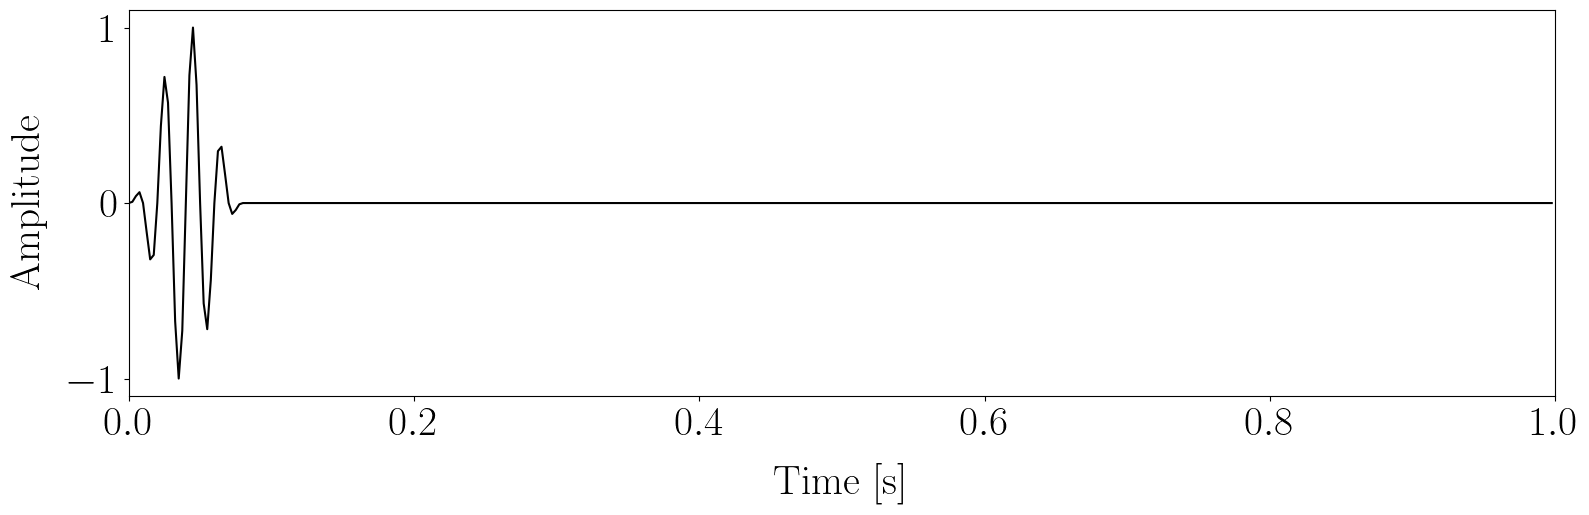

In [8]:
# Plot source signal 
lfig = LargeFigure()
plt.figure()
plt.plot(t, s, color="k")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.xlim([0, 1]) 

# Save figure as pdf    
fpath = os.path.join(folder_root, "pekeris_waveguide_dispersion_source_signal.pdf")
plt.savefig(fpath, dpi=300)

In [9]:
km = KrakenManager()
pressure_field, field_pos = km.runkraken(
    env=k_tc.env, flp=k_tc.flp, frequencies=k_tc.src.freq
)

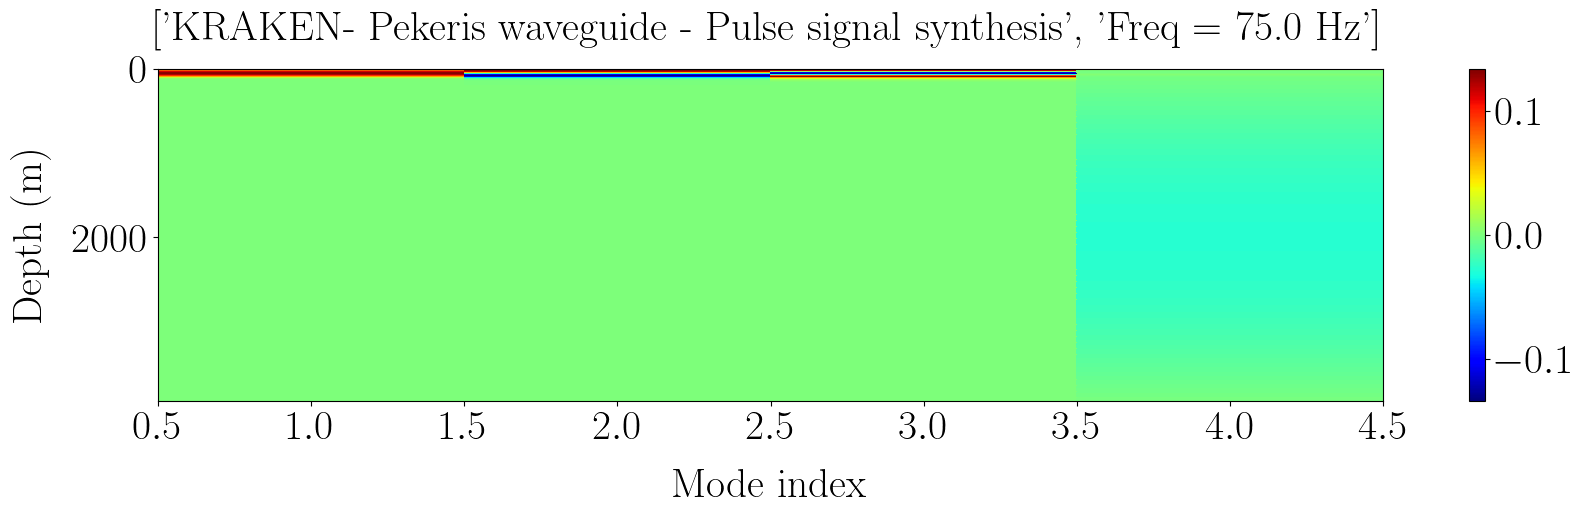

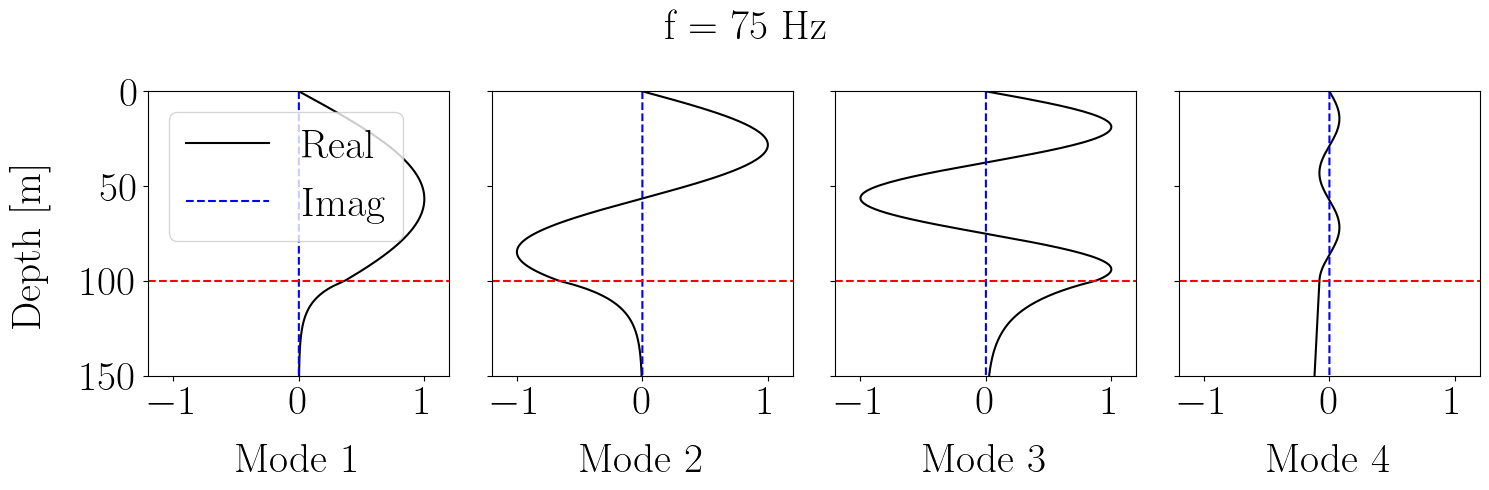

In [10]:
lfig = LargeFigure()

f_visu = 75  # Frequency to visualize
fpath = os.path.join(k_tc.io_files_dir, k_tc.env.filename)
# plotmode(fpath, freq=k_tc.src.freq, modes=[1, 2, 3, 4], bathy_depth=k_tc.bathy.bathy_depth[0], normalize_mode=True)
plotmode(
    fpath,
    freq=[f_visu],
    modes=[1, 2, 3, 4],
    bathy_depth=k_tc.bathy.bathy_depth[0],
    normalize_mode=True,
)

fig = plt.gcf()
plt.ylim([150, 0])
fig.suptitle(f"f = {f_visu} Hz")
# fig.supylabel("Depth [m]")

# Save figure as pdf
fpath = os.path.join(folder_root, "pekeris_waveguide_4modes.pdf")
plt.savefig(fpath, dpi=300)

### Remarques 

La fréquence de coupure pour le guide d'onde de Pekeris est donnée par

$
f_{0m} = \frac{(m - 0.5) c_w}{2D\sqrt{1-(\frac{c_w}{c_b})^2}}
$

i.e pour le pulse considéré de fréquence centrale fc = 50 Hz et de largeur de bande 50 Hz (B = [25, 75] Hz) seul les trois premiers modes existent (sont propagatifs)

In [11]:
root = os.path.join(folder_root, "data")
tf_fpath = os.path.join(root, "transfer_functions.nc")
sig_fpath = os.path.join(root, "received_signals.nc")

In [12]:
# Store pressure field as netcdf using xarray
pressure_field = np.squeeze(pressure_field)  # Remove singleton dimensions if any
ds_tf = xr.Dataset(
    data_vars=dict(
        tf_real=(["f", "z", "r"], np.real(pressure_field)),
        tf_imag=(["f", "z", "r"], np.imag(pressure_field)),
    ),
    coords=dict(
        f=k_tc.src.freq,
        z=field_pos["r"]["z"],
        r=field_pos["r"]["r"],
    ),
)
# Save to netcdf
ds_tf.to_netcdf(tf_fpath)

In [13]:
# # Compare to runtest
# fpath_runtest = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\kraken_toolbox\tests\calibrationSynthesis\pf.nc"
# ds_tf_runtest = xr.open_dataset(fpath_runtest)

# # # Align z coordinates
# # ds_tf = ds_tf.sel(z=ds_tf_old.z, method="nearest")
# # # Align r coordinates
# # ds_tf_old = ds_tf_old.sel(r=ds_tf.r, method="nearest")

# print(np.allclose(ds_tf.tf_real.values, ds_tf_runtest.tf_real.values))
# print(np.allclose(ds_tf.tf_imag.values, ds_tf_runtest.tf_imag.values))

In [14]:
# Load transfert functions if no need to recompute
ds_tf = xr.open_dataset(tf_fpath)  # (nf, nz, nr)

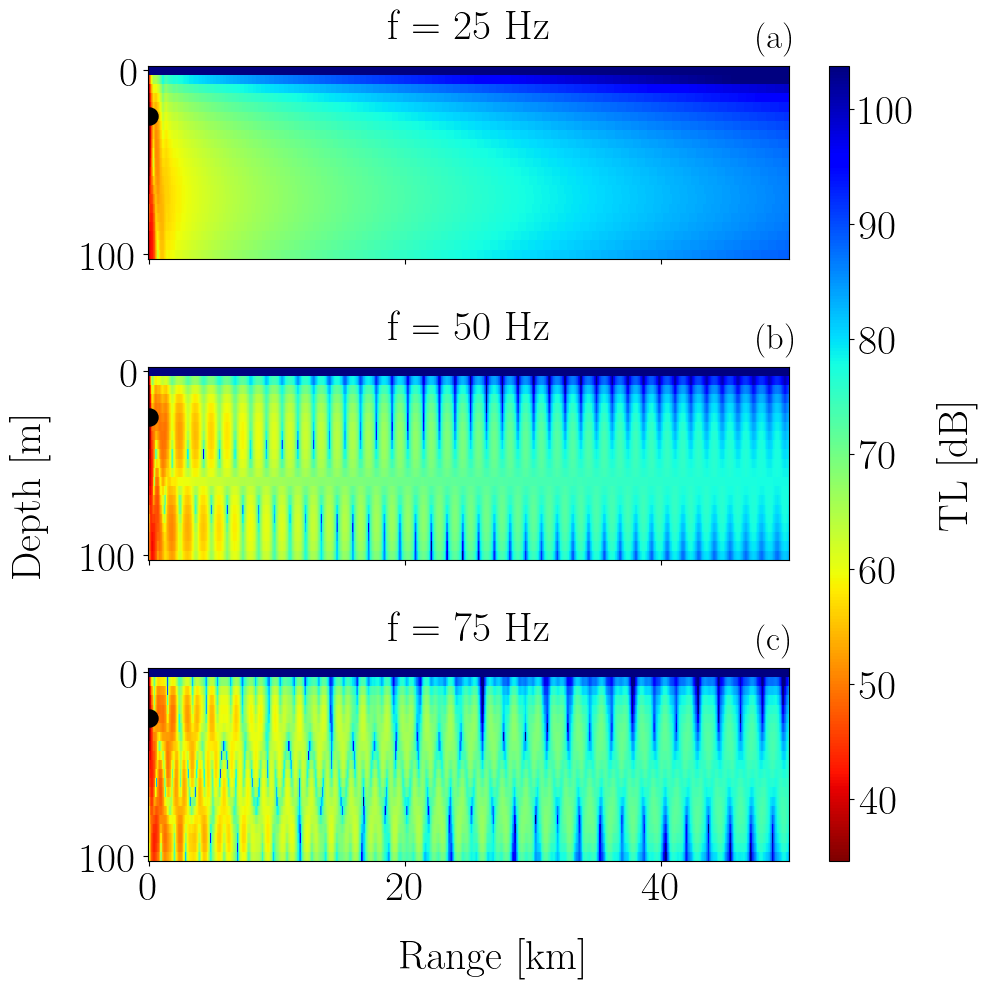

In [15]:
lfig = LargeFigure(size=(16, 7.5))

# Plot tl at a single frequency
tf = ds_tf.tf_real + 1j * ds_tf.tf_imag  # (nf, nz, nr)
freq_plot = [25, 50, 75]
p_field = tf.sel(f=freq_plot, method="nearest").values
p_field[(p_field == 0) | np.isnan(p_field)] = 1e-20
tl = -20 * np.log10(np.abs(p_field))
tlmax = np.percentile(tl, 95)
tlmin = np.percentile(tl, 1) - 15

# Plot TL for each number of modes
fig, axs = plt.subplots(len(freq_plot), figsize=(10, 10), sharex=True)
abcd_labels = ["a", "b", "c"]
for i, fp in enumerate(freq_plot):
    p_field = p_field[i, ...]
    title = f"f = {fp} Hz"

    # Plot TL
    im = axs[i].pcolormesh(tf.r * 1e-3, tf.z, tl[i], cmap="jet_r", vmin=tlmin, vmax=tlmax, rasterized=True)

    # Add source position
    if z_src is not None:
        axs[i].scatter(
            0,
            z_src,
            color="k",
            marker="o",
            s=150,
        )
    axs[i].set_title(title)
    axs[i].invert_yaxis()

    # Add a, b, c labels
    axs[i].text(
        0.95,
        1.05,
        f"({abcd_labels[i]})",
        transform=axs[i].transAxes,
        fontsize=25,
        fontweight="bold",
        va="bottom",
    )

fig.supxlabel("Range [km]")
fig.supylabel("Depth [m]")

# Add common colorbar
cbar = fig.colorbar(im, ax=axs, orientation="vertical", pad=0.05, aspect=40)
cbar.set_label("TL [dB]")

# Save figure as pdf
fpath = os.path.join(folder_root, "ideal_waveguide_tl_modes.pdf")
plt.savefig(fpath)

In [16]:
rmin_visu = 15 * 1e3  # Minimum range for visualization
rmax_visu = 45 * 1e3  # Maximum range for visualization
ds_tf = ds_tf.sel(r=slice(rmin_visu, rmax_visu))  # Select receivers at 30 km range
rcv_range = ds_tf.r.values
# rcv_range = np.array([30 * 1e3])  

delays = rcv_range / g.c0
rcv_depth = np.linspace(k_tc.flp.rcv_z_min, k_tc.flp.rcv_z_max, k_tc.flp.n_rcv_z)

In [17]:
# Source spectrum
Sf = src.positive_spectrum
fmin = np.min(ds_tf.f.values)
idx_first_freq = np.argmin(np.abs(src.positive_freq - fmin))
Sf = Sf[idx_first_freq:]  

# Derive delay for each receiver
tau_rcv = ds_tf.r.min().values / g.c0
# tau_rcv = target_range / g.c0


tf = ds_tf.tf_real + 1j * ds_tf.tf_imag # (nf, nz, nr)

# Derive received spectrum (Y = SH)
k0 = 2 * np.pi * ds_tf.f.values / g.c0
norm_factor = np.exp(1j * k0) / (4 * np.pi)

# # Derive delay factor to take into account the propagation time
delay_rcv = np.exp(1j * 2 * np.pi * tau_rcv * ds_tf.f.values)  # (nf,)

y_f = mult_along_axis(tf, Sf*norm_factor*delay_rcv, axis=0)

nfft_inv = (
    4 * src.nfft
)  # according to Jensen et al. (2000) p.616 : dt < 1 / (8 * fmax) for visual inspection of the propagated pulse
T_tot = 1 / src.df
dt = T_tot / nfft_inv
time_vector = np.arange(0, T_tot, dt)

# FFT inv to get signal
y_t = np.fft.irfft(y_f, axis=0, n=nfft_inv)  # (nt, nz, nr)
y_t = np.real(y_t)  # Keep only real part

# Build dataset to save
ds_sig = xr.Dataset(
    coords=dict(
        t=time_vector,
        z=ds_tf.z,
        r=ds_tf.r,
    ),
    data_vars=dict(
        s=(["t", "z", "r"], y_t),
    ),
)

# Save dataset
ds_sig.to_netcdf(sig_fpath)

In [18]:
# Load data if no need to recompute
ds_sig = xr.open_dataset(sig_fpath)

In [19]:
# # Plot signal at a given receiver depth, range
# rcv_depth = 30
# rcv_range = 30 * 1e3

# plt.figure()
# ds_sig.s.sel(z=rcv_depth, r=rcv_range).plot()

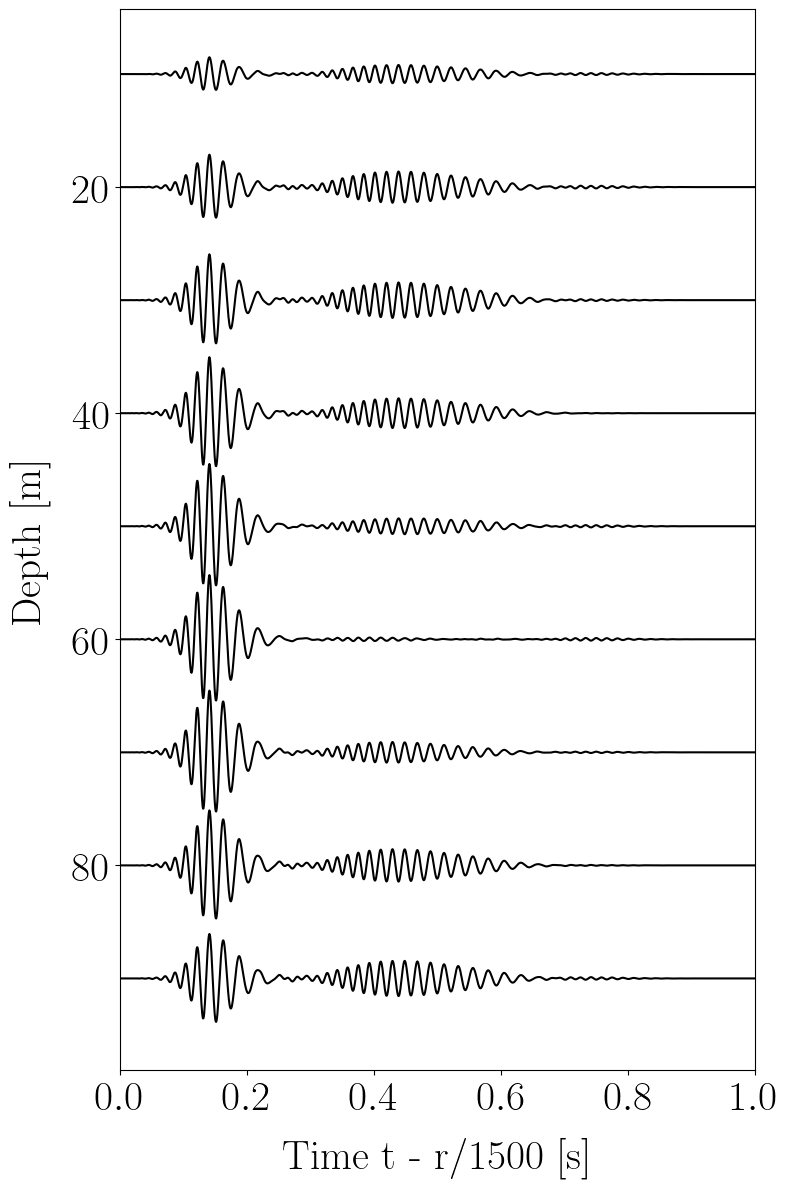

In [20]:
range_plot = np.array([30000])
depth_plot = np.arange(10, 100, 10)  # Depths to plot

# Scale for visualization
max_amplitude = ds_sig.s.max().values
alpha_dilatation = 12
ds_sig["s"] = ds_sig.s / max_amplitude * alpha_dilatation

# Roll over time axis to start at zero
tau_roll = (range_plot[0]-ds_sig.r.min().values) / g.c0  # Roll time axis to start at zero
ts = ds_sig.t.diff("t").values[0]
idx_tau_roll = int(tau_roll / ts)  
sig_roll = ds_sig.s.roll(t=-idx_tau_roll, roll_coords=False)

z_offset = depth_plot[1] - depth_plot[0]
for ir, r in enumerate(range_plot):
    plt.figure(figsize=(8, 12))
    for iz, z in enumerate(depth_plot):
        sig = sig_roll.sel(z=z, r=r, method="nearest") + (iz + 1) * z_offset
        if z == z_src:
            sig.plot(color="r", label="Source depth")
        else:
            sig.plot(color="k")

    # Revert y-axis
    ax = plt.gca()
    ax.invert_yaxis()
    plt.xlim([0, 1])
    plt.xlabel(f"Time  t - r/{g.c0} [s]")
    plt.ylabel("Depth [m]")
    plt.title(
        "",
    )
    # Save figure as pdf
    fpath = os.path.join(folder_root, "perkeris_waveguide_pulse_dispersion_30km_z.pdf")
    plt.savefig(fpath)